# Deep Dive into Deep Learning Optimizers
### A Comparative Empirical & Theoretical Study: SGD, Momentum, AdaGrad, RMSProp, Adam & Nadam

> **Seminar Presenters:**  
> • **Kunal (Presenter 1):** Foundations, Standard SGD & SGD with Momentum  
> • **Rahul (Presenter 2):** Adaptive Learning Rates, AdaGrad & RMSProp  
> • **Pankaj (Presenter 3):** Adam, Nadam & The Generalization Mystery  
> • **All Members:** Benchmark Walkthrough, Architecture Pipelines, Hand-Calculations & Viva Defense  

---

### Notebook Architecture
1. **Foundations & Core Math:** Loss Surfaces, Gradients, Step Size & Parameter Updates
2. **Setup & Controls:** Fashion-MNIST (1,000 Samples) & BenchmarkMLP Architecture
3. **Individual Optimizer Deep-Dives (Separate Cells & Plots):**
   - **Kunal:** Optimizer 1 (Standard SGD) & Optimizer 2 (SGD + Momentum)
   - **Rahul:** Optimizer 3 (AdaGrad) & Optimizer 4 (RMSProp)
   - **Pankaj:** Optimizer 5 (Adam) & Optimizer 6 (Nadam)
4. **Master Combined Dashboard:** All 6 curves overlaid side-by-side & Final Comparison Table
5. **Learning-Rate Sensitivity Test:** Evaluating stability across 4 decades ($10^{-1}$ to $10^{-4}$)
6. **The Generalization Mystery:** Why Fast Optimization $\neq$ Best Model Quality (Flat vs. Sharp Minima)
7. **Viva Oral Defense Cheat Sheet:** 10-Second Answers for Teacher Questions


## 1. Mathematical Foundations of Optimization

### The Core Update Equation
Every gradient-based optimizer iteratively refines model parameters $\theta$ by stepping opposite to the gradient vector:
$$\theta_{t+1} = \theta_t - \Delta \theta_t$$
where the gradient is the vector of all first-order partial derivatives of the loss function:
$$g_t = \nabla_\theta L(\theta_t) = \left[ \frac{\partial L}{\partial \theta_1}, \frac{\partial L}{\partial \theta_2}, \dots, \frac{\partial L}{\partial \theta_d} \right]^T$$

The difference between optimizers lies in **how they calculate $\Delta \theta_t$**:
* Does it use only instantaneous slope? (SGD)
* Does it build directional inertia? (Momentum)
* Does it adaptively scale each coordinate? (AdaGrad, RMSProp)
* Does it combine velocity, scaling, and lookahead? (Adam, Nadam)


In [1]:
# -------------------------------------------------------------
# STEP 1: Libraries, Device, Reproducibility & 1,000-Sample Dataset
# -------------------------------------------------------------
import os
import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Set fixed seed for 100% scientific reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[OK] Training environment configured on: {device}")

# Preprocessing: Normalize Fashion-MNIST images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_full = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# USE EXACTLY 1,000 SAMPLES (~100 images per clothing category)
# This provides realistic non-convex training while allowing each optimizer
# to finish all 10 epochs in under 8.5 seconds on CPU!
train_subset = Subset(train_full, list(range(1000)))
val_subset = Subset(test_full, list(range(1000)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)

print(f"[OK] Dataset configured: {len(train_subset)} training images, {len(val_subset)} validation images.")


[OK] Training environment configured on: cpu
[OK] Dataset configured: 1000 training images, 1000 validation images.


In [2]:
# -------------------------------------------------------------
# STEP 2: Neural Network Architecture & Weight Cloning
# -------------------------------------------------------------
# 3-Layer MLP: 784 -> 128 (ReLU) -> 64 (ReLU) -> 10 (Logits)
class BenchmarkMLP(nn.Module):
    def __init__(self):
        super(BenchmarkMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

# Create reference model and freeze initial weights theta_0
# Every single optimizer will begin its training path from this exact same point!
reference_model = BenchmarkMLP().to(device)
initial_weights = copy.deepcopy(reference_model.state_dict())
criterion = nn.CrossEntropyLoss()

def evaluate_model(model, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return total_loss / total, (correct / total) * 100.0


def train_and_plot_optimizer(opt_name, get_opt_fn, color_hex, epochs=10):
    """Trains one optimizer, prints epoch logs, and plots its individual loss/accuracy curves."""
    print(f"==================== Training: {opt_name} ====================")
    model = BenchmarkMLP().to(device)
    model.load_state_dict(copy.deepcopy(initial_weights))
    optimizer = get_opt_fn(model)
    
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            total += x.size(0)
            
        train_l = running_loss / total
        val_l, val_a = evaluate_model(model, val_loader)
        history["train_loss"].append(train_l)
        history["val_loss"].append(val_l)
        history["val_acc"].append(val_a)
        print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_a:.2f}%")
        
    duration = time.time() - start_time
    print(f"[+] Finished {opt_name} in {duration:.2f}s")
    
    # Render dedicated individual 2-panel figure for this optimizer
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    epochs_range = list(range(1, epochs + 1))
    
    # Subplot 1: Train Loss vs Val Loss
    ax1.plot(epochs_range, history["train_loss"], marker='o', color=color_hex, linewidth=2, label='Train Loss')
    ax1.plot(epochs_range, history["val_loss"], marker='s', color='#7f8c8d', linestyle='--', linewidth=2, label='Val Loss')
    ax1.set_title(f"{opt_name} - Loss Trajectory", fontsize=11, fontweight='bold')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.6)
    
    # Subplot 2: Validation Accuracy
    ax2.plot(epochs_range, history["val_acc"], marker='^', color=color_hex, linewidth=2, label='Val Accuracy')
    ax2.set_title(f"{opt_name} - Validation Accuracy (%)", fontsize=11, fontweight='bold')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    os.makedirs("./plots", exist_ok=True)
    fname_map = {
        "SGD": "01_sgd_benchmark.png",
        "SGD + Momentum": "02_momentum_benchmark.png",
        "AdaGrad": "03_adagrad_benchmark.png",
        "RMSProp": "04_rmsprop_benchmark.png",
        "Adam": "05_adam_benchmark.png",
        "Nadam": "06_nadam_benchmark.png"
    }
    if opt_name in fname_map:
        fig.savefig(f"./plots/{fname_map[opt_name]}", dpi=200, bbox_inches='tight')
    plt.show()
    
    return history, duration

# Master dictionary to store histories for the final combined dashboard
all_benchmark_results = {}
summary_table_rows = []
print("[OK] Training engine and individual plotter ready.")


[OK] Training engine and individual plotter ready.


## 3. Optimizer 1: Stochastic Gradient Descent (SGD)
* **Presenter:** Kunal  
* **Formula:** $\theta_{t+1} = \theta_t - \eta \cdot g_t$  
* **Internal Memory:** 0 buffers (purely reactive)  
* **Analogy:** Blind hiker taking quick, noisy steps  
* **Behavior:** Simple and fast per step, but oscillates violently across steep ravines.


==================== Training: SGD ====================
  Epoch [01/10] | Train Loss: 2.1270 | Val Loss: 1.8502 | Val Acc: 47.50%
  Epoch [02/10] | Train Loss: 1.5197 | Val Loss: 1.2593 | Val Acc: 60.20%
  Epoch [03/10] | Train Loss: 1.0533 | Val Loss: 0.9838 | Val Acc: 66.50%
  Epoch [04/10] | Train Loss: 0.8772 | Val Loss: 0.8460 | Val Acc: 69.80%
  Epoch [05/10] | Train Loss: 0.7575 | Val Loss: 0.7914 | Val Acc: 72.00%
  Epoch [06/10] | Train Loss: 0.6979 | Val Loss: 0.7760 | Val Acc: 72.80%
  Epoch [07/10] | Train Loss: 0.6518 | Val Loss: 0.7120 | Val Acc: 73.90%
  Epoch [08/10] | Train Loss: 0.5733 | Val Loss: 0.6972 | Val Acc: 73.30%
  Epoch [09/10] | Train Loss: 0.5468 | Val Loss: 0.6652 | Val Acc: 75.90%
  Epoch [10/10] | Train Loss: 0.5142 | Val Loss: 0.6549 | Val Acc: 75.10%
[+] Finished SGD in 10.72s


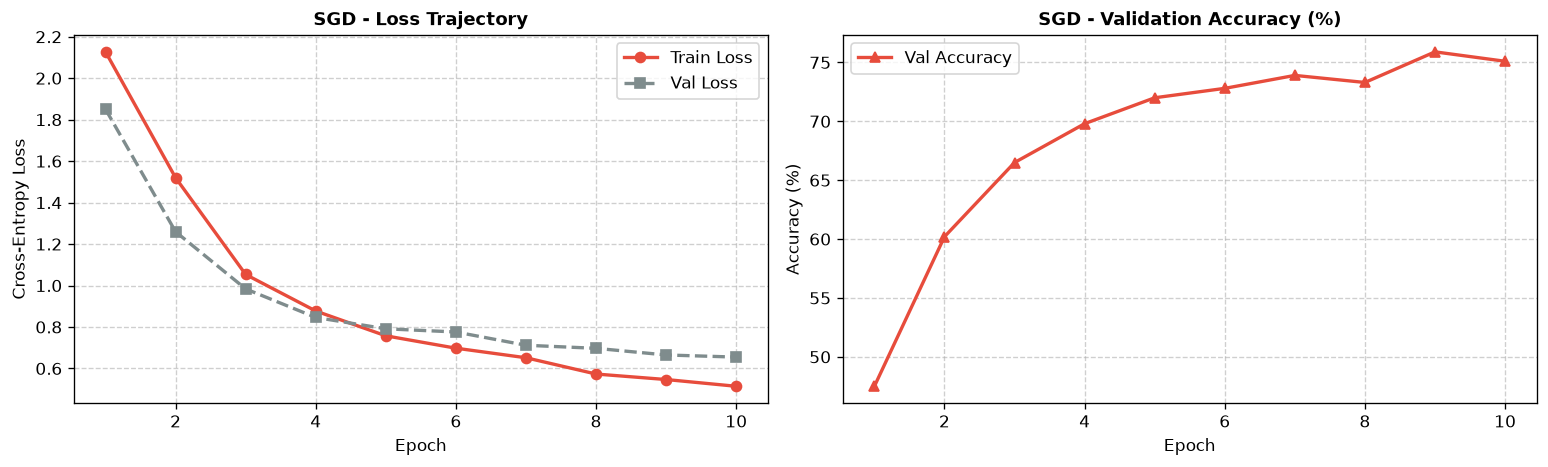

In [3]:
# Run Optimizer 1: Standard SGD
opt_name = "SGD"
get_opt = lambda m: optim.SGD(m.parameters(), lr=0.05)
color = "#e74c3c"  # Red

hist, dur = train_and_plot_optimizer(opt_name, get_opt, color, epochs=10)
all_benchmark_results[opt_name] = hist
summary_table_rows.append({
    "Optimizer": opt_name,
    "Final Train Loss": round(hist["train_loss"][-1], 4),
    "Final Val Loss": round(hist["val_loss"][-1], 4),
    "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist["val_acc"]), 2),
    "Total Time (s)": round(dur, 2)
})


## 4. Optimizer 2: SGD with Momentum
* **Presenter:** Kunal  
* **Formula:** $v_{t+1} = \gamma v_t + \eta g_t, \quad \theta_{t+1} = \theta_t - v_{t+1}$  
* **Internal Memory:** 1 Velocity buffer ($v_t$)  
* **Analogy:** Heavy bowling ball rolling down a valley  
* **Advantage:** Alternating lateral oscillations cancel out, while down-valley momentum accelerates forward.


==================== Training: SGD + Momentum ====================
  Epoch [01/10] | Train Loss: 2.0480 | Val Loss: 1.4596 | Val Acc: 51.80%
  Epoch [02/10] | Train Loss: 1.0337 | Val Loss: 0.8941 | Val Acc: 66.10%
  Epoch [03/10] | Train Loss: 0.7479 | Val Loss: 0.7581 | Val Acc: 70.90%
  Epoch [04/10] | Train Loss: 0.6035 | Val Loss: 0.7344 | Val Acc: 69.30%
  Epoch [05/10] | Train Loss: 0.5037 | Val Loss: 0.6703 | Val Acc: 74.80%
  Epoch [06/10] | Train Loss: 0.4359 | Val Loss: 0.6307 | Val Acc: 76.00%
  Epoch [07/10] | Train Loss: 0.3807 | Val Loss: 0.6663 | Val Acc: 77.90%
  Epoch [08/10] | Train Loss: 0.3794 | Val Loss: 0.6192 | Val Acc: 77.80%
  Epoch [09/10] | Train Loss: 0.3510 | Val Loss: 0.6148 | Val Acc: 79.60%
  Epoch [10/10] | Train Loss: 0.3097 | Val Loss: 0.6583 | Val Acc: 78.10%
[+] Finished SGD + Momentum in 10.87s


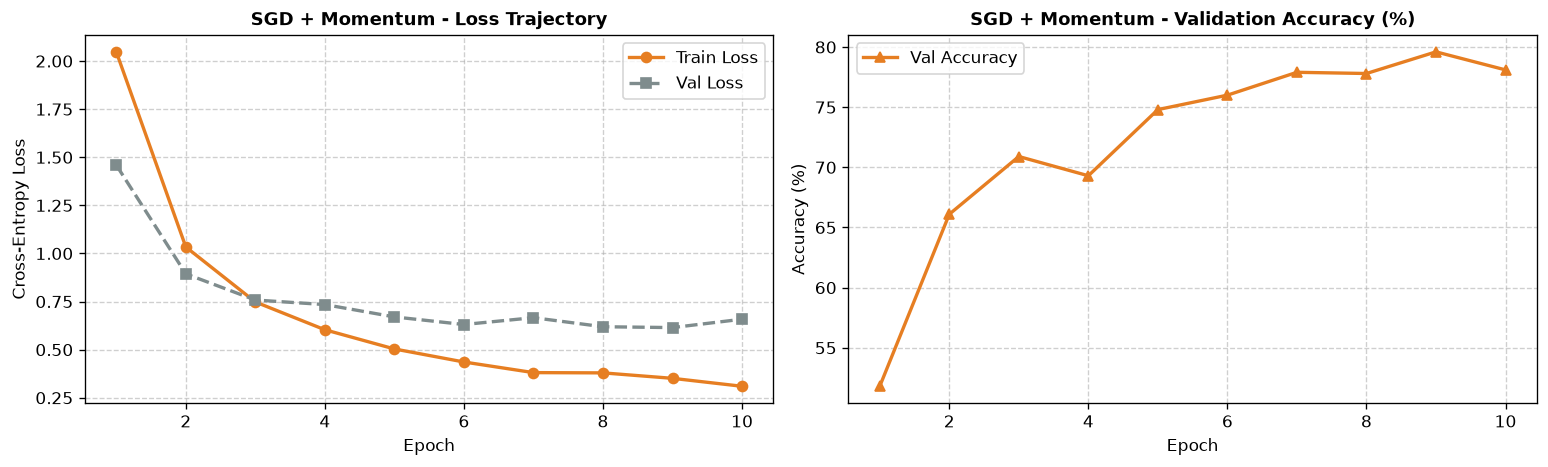

In [4]:
# Run Optimizer 2: SGD with Momentum
opt_name = "SGD + Momentum"
get_opt = lambda m: optim.SGD(m.parameters(), lr=0.02, momentum=0.9)
color = "#e67e22"  # Orange

hist, dur = train_and_plot_optimizer(opt_name, get_opt, color, epochs=10)
all_benchmark_results[opt_name] = hist
summary_table_rows.append({
    "Optimizer": opt_name,
    "Final Train Loss": round(hist["train_loss"][-1], 4),
    "Final Val Loss": round(hist["val_loss"][-1], 4),
    "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist["val_acc"]), 2),
    "Total Time (s)": round(dur, 2)
})


## 5. Optimizer 3: AdaGrad (Adaptive Gradient)
* **Presenter:** Rahul  
* **Formula:** $G_t = G_{t-1} + g_t^2, \quad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} g_t$  
* **Internal Memory:** 1 Cumulative squared gradient buffer ($G_t$)  
* **Analogy:** Elephant that remembers every mistake since birth  
* **Limitation:** $G_t$ grows monotonically, causing the learning rate to vanish and freezing learning early.


==================== Training: AdaGrad ====================
  Epoch [01/10] | Train Loss: 1.3626 | Val Loss: 0.8372 | Val Acc: 71.80%
  Epoch [02/10] | Train Loss: 0.7087 | Val Loss: 0.7604 | Val Acc: 70.10%
  Epoch [03/10] | Train Loss: 0.5772 | Val Loss: 0.6553 | Val Acc: 76.90%
  Epoch [04/10] | Train Loss: 0.4999 | Val Loss: 0.5969 | Val Acc: 77.20%
  Epoch [05/10] | Train Loss: 0.4201 | Val Loss: 0.7362 | Val Acc: 70.10%
  Epoch [06/10] | Train Loss: 0.3936 | Val Loss: 0.5983 | Val Acc: 78.20%
  Epoch [07/10] | Train Loss: 0.3503 | Val Loss: 0.6450 | Val Acc: 75.00%
  Epoch [08/10] | Train Loss: 0.3181 | Val Loss: 0.6002 | Val Acc: 79.30%
  Epoch [09/10] | Train Loss: 0.3031 | Val Loss: 0.5710 | Val Acc: 80.00%
  Epoch [10/10] | Train Loss: 0.2629 | Val Loss: 0.5982 | Val Acc: 79.80%
[+] Finished AdaGrad in 11.07s


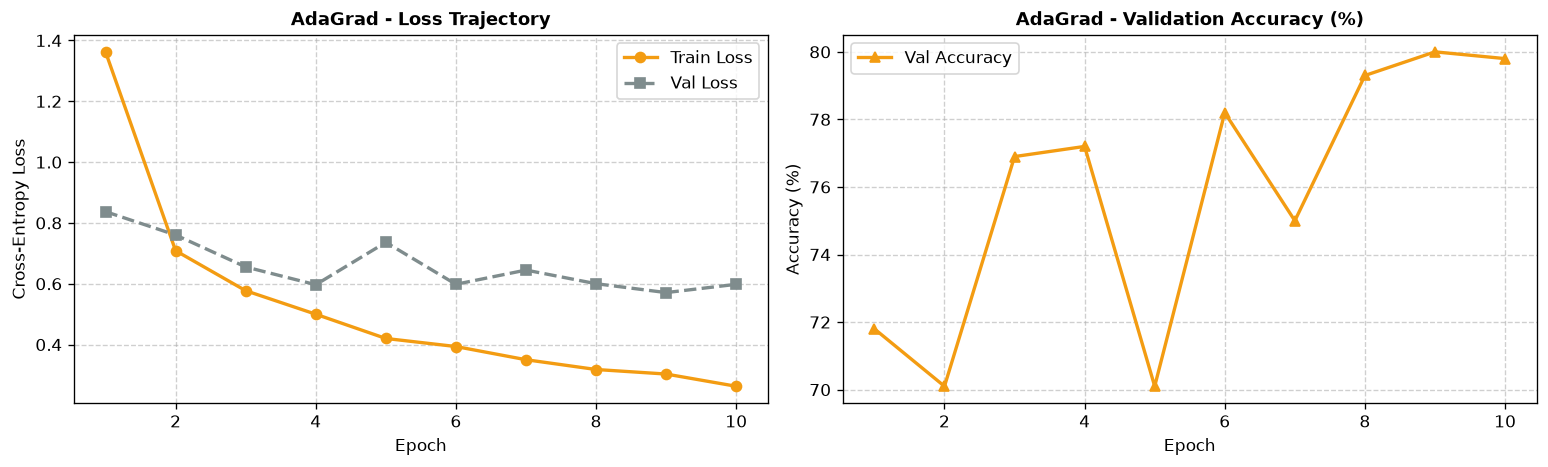

In [5]:
# Run Optimizer 3: AdaGrad
opt_name = "AdaGrad"
get_opt = lambda m: optim.Adagrad(m.parameters(), lr=0.01)
color = "#f39c12"  # Amber

hist, dur = train_and_plot_optimizer(opt_name, get_opt, color, epochs=10)
all_benchmark_results[opt_name] = hist
summary_table_rows.append({
    "Optimizer": opt_name,
    "Final Train Loss": round(hist["train_loss"][-1], 4),
    "Final Val Loss": round(hist["val_loss"][-1], 4),
    "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist["val_acc"]), 2),
    "Total Time (s)": round(dur, 2)
})


## 6. Optimizer 4: RMSProp
* **Presenter:** Rahul  
* **Formula:** $v_t = \beta v_{t-1} + (1-\beta) g_t^2, \quad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{v_t + \epsilon}} g_t$  
* **Internal Memory:** 1 Leaky exponential moving average buffer ($v_t$)  
* **Analogy:** Practical human who focuses on recent performance and forgets ancient mistakes  
* **Advantage:** Cures AdaGrad's vanishing learning rate; ideal for non-stationary problems and RNNs.


==================== Training: RMSProp ====================
  Epoch [01/10] | Train Loss: 1.3976 | Val Loss: 0.9665 | Val Acc: 66.40%
  Epoch [02/10] | Train Loss: 0.7924 | Val Loss: 0.7670 | Val Acc: 71.40%
  Epoch [03/10] | Train Loss: 0.6477 | Val Loss: 0.7096 | Val Acc: 74.20%
  Epoch [04/10] | Train Loss: 0.5717 | Val Loss: 0.6536 | Val Acc: 77.70%
  Epoch [05/10] | Train Loss: 0.4917 | Val Loss: 0.6831 | Val Acc: 76.40%
  Epoch [06/10] | Train Loss: 0.4546 | Val Loss: 0.7152 | Val Acc: 72.90%
  Epoch [07/10] | Train Loss: 0.4369 | Val Loss: 0.6198 | Val Acc: 78.10%
  Epoch [08/10] | Train Loss: 0.3935 | Val Loss: 0.5757 | Val Acc: 79.20%
  Epoch [09/10] | Train Loss: 0.3556 | Val Loss: 0.5576 | Val Acc: 79.90%
  Epoch [10/10] | Train Loss: 0.3147 | Val Loss: 0.7311 | Val Acc: 74.90%
[+] Finished RMSProp in 11.11s


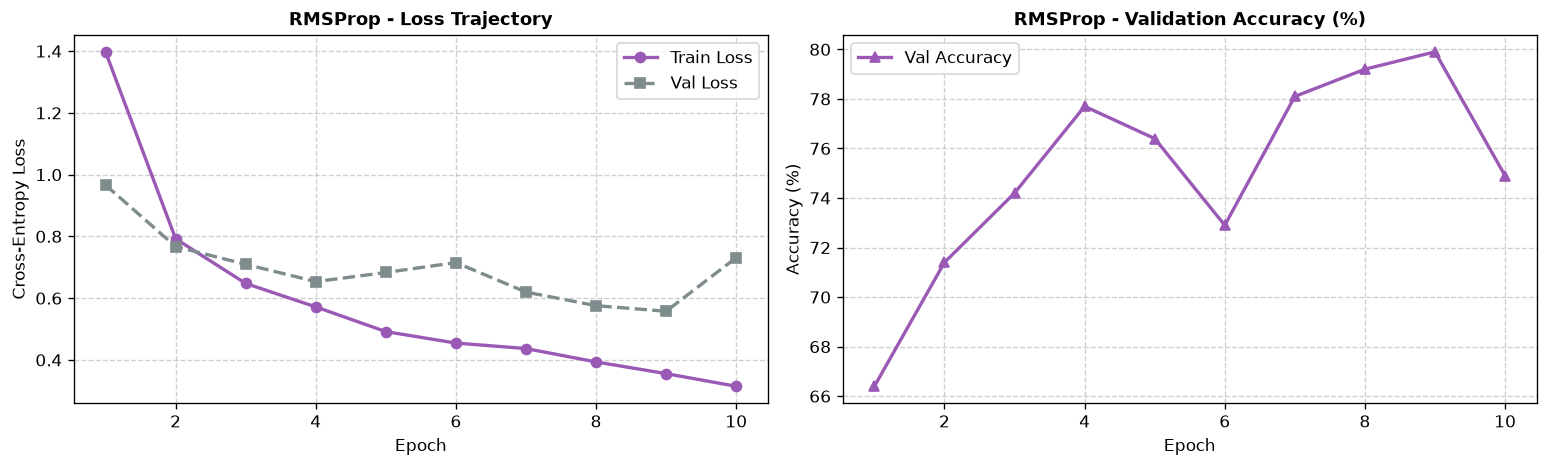

In [6]:
# Run Optimizer 4: RMSProp
opt_name = "RMSProp"
get_opt = lambda m: optim.RMSprop(m.parameters(), lr=0.001, alpha=0.9)
color = "#9b59b6"  # Purple

hist, dur = train_and_plot_optimizer(opt_name, get_opt, color, epochs=10)
all_benchmark_results[opt_name] = hist
summary_table_rows.append({
    "Optimizer": opt_name,
    "Final Train Loss": round(hist["train_loss"][-1], 4),
    "Final Val Loss": round(hist["val_loss"][-1], 4),
    "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist["val_acc"]), 2),
    "Total Time (s)": round(dur, 2)
})


## 7. Optimizer 5: Adam (Adaptive Moment Estimation)
* **Presenter:** Pankaj  
* **Formula:** $\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \quad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$  
* **Internal Memory:** 2 State buffers ($m_t$ for velocity, $v_t$ for adaptive variance)  
* **Analogy:** High-speed vehicle with an active smart suspension system  
* **Advantage:** Fast convergence, robust defaults, works out-of-the-box across nearly every deep learning architecture.


==================== Training: Adam ====================
  Epoch [01/10] | Train Loss: 1.6581 | Val Loss: 1.0395 | Val Acc: 64.40%
  Epoch [02/10] | Train Loss: 0.8225 | Val Loss: 0.7619 | Val Acc: 69.90%
  Epoch [03/10] | Train Loss: 0.6233 | Val Loss: 0.6800 | Val Acc: 75.60%
  Epoch [04/10] | Train Loss: 0.5245 | Val Loss: 0.6428 | Val Acc: 77.40%
  Epoch [05/10] | Train Loss: 0.4627 | Val Loss: 0.6407 | Val Acc: 77.50%
  Epoch [06/10] | Train Loss: 0.4340 | Val Loss: 0.6761 | Val Acc: 76.30%
  Epoch [07/10] | Train Loss: 0.3898 | Val Loss: 0.5742 | Val Acc: 80.10%
  Epoch [08/10] | Train Loss: 0.3292 | Val Loss: 0.6173 | Val Acc: 77.50%
  Epoch [09/10] | Train Loss: 0.3129 | Val Loss: 0.5680 | Val Acc: 79.20%
  Epoch [10/10] | Train Loss: 0.2719 | Val Loss: 0.5817 | Val Acc: 79.40%
[+] Finished Adam in 11.44s


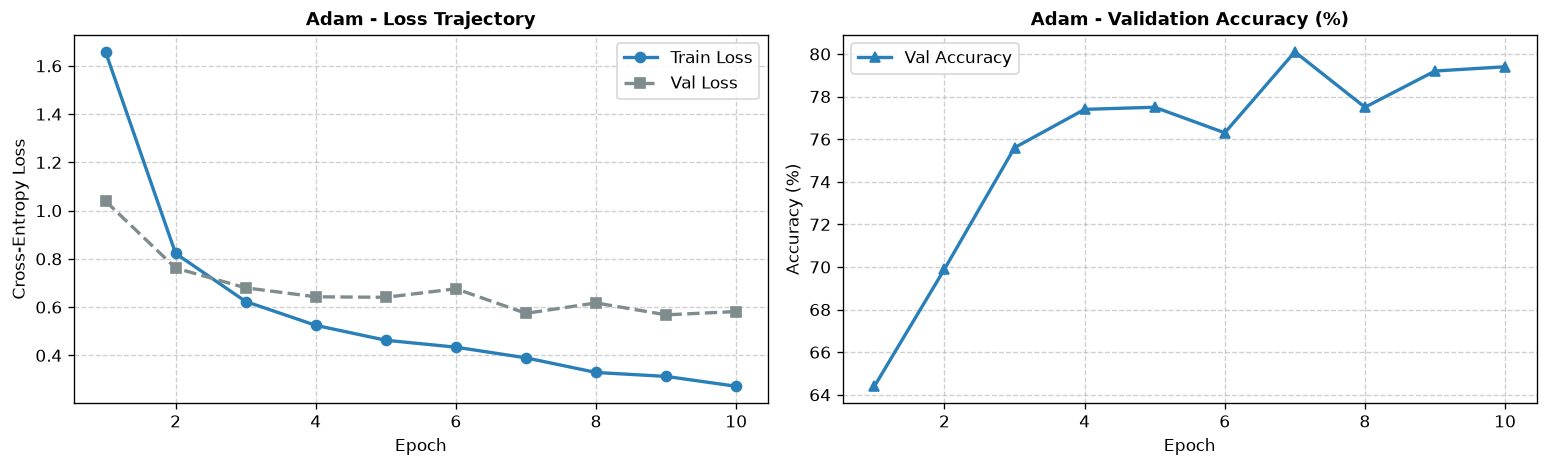

In [7]:
# Run Optimizer 5: Adam
opt_name = "Adam"
get_opt = lambda m: optim.Adam(m.parameters(), lr=0.001, betas=(0.9, 0.999))
color = "#2980b9"  # Blue

hist, dur = train_and_plot_optimizer(opt_name, get_opt, color, epochs=10)
all_benchmark_results[opt_name] = hist
summary_table_rows.append({
    "Optimizer": opt_name,
    "Final Train Loss": round(hist["train_loss"][-1], 4),
    "Final Val Loss": round(hist["val_loss"][-1], 4),
    "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist["val_acc"]), 2),
    "Total Time (s)": round(dur, 2)
})


## 8. Optimizer 6: Nadam (Nesterov-accelerated Adam)
* **Presenter:** Pankaj  
* **Formula:** $\bar{m}_t = \beta_1 \hat{m}_t + \left( \frac{1-\beta_1}{1-\beta_1^t} \right) g_t, \quad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \bar{m}_t$  
* **Internal Memory:** 2 State buffers with Nesterov lookahead computation  
* **Analogy:** Racecar driver applying anticipatory braking before turning into a corner  
* **Advantage:** Prevents overshooting steep ravines and improves stability on high-curvature surfaces.


==================== Training: Nadam ====================
  Epoch [01/10] | Train Loss: 1.6551 | Val Loss: 1.0236 | Val Acc: 66.00%
  Epoch [02/10] | Train Loss: 0.8061 | Val Loss: 0.7214 | Val Acc: 73.60%
  Epoch [03/10] | Train Loss: 0.6251 | Val Loss: 0.6498 | Val Acc: 77.40%
  Epoch [04/10] | Train Loss: 0.5297 | Val Loss: 0.6749 | Val Acc: 74.20%
  Epoch [05/10] | Train Loss: 0.4536 | Val Loss: 0.7477 | Val Acc: 73.80%
  Epoch [06/10] | Train Loss: 0.4131 | Val Loss: 0.5939 | Val Acc: 78.50%
  Epoch [07/10] | Train Loss: 0.3637 | Val Loss: 0.6309 | Val Acc: 77.60%
  Epoch [08/10] | Train Loss: 0.3210 | Val Loss: 0.5706 | Val Acc: 80.30%
  Epoch [09/10] | Train Loss: 0.2972 | Val Loss: 0.6676 | Val Acc: 75.00%
  Epoch [10/10] | Train Loss: 0.2828 | Val Loss: 0.6255 | Val Acc: 77.60%
[+] Finished Nadam in 11.96s


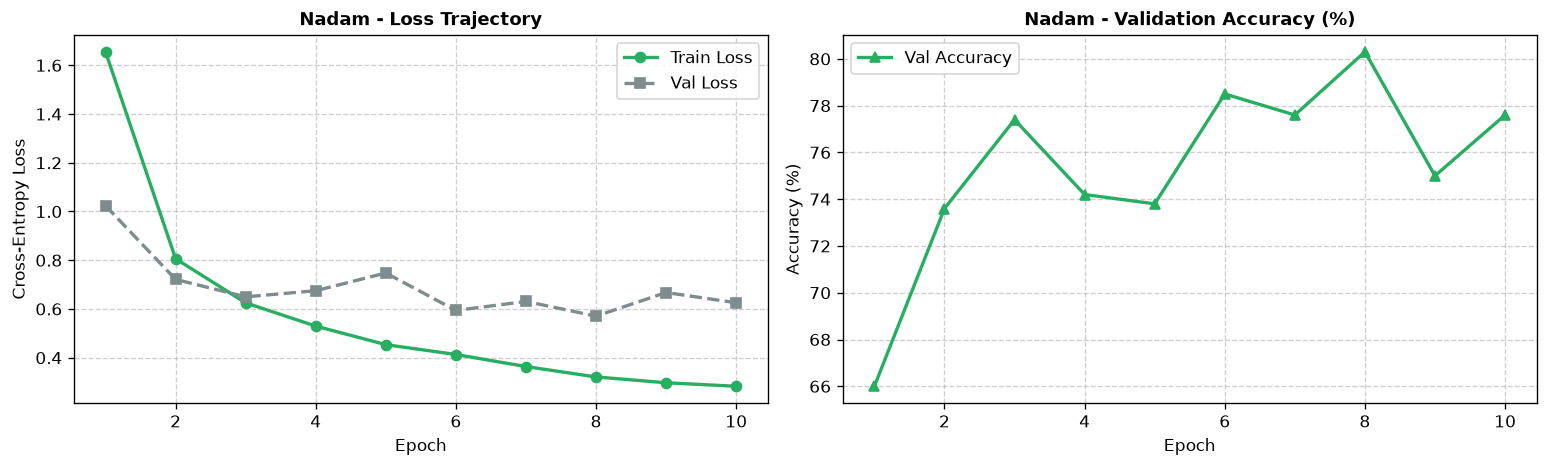

In [8]:
# Run Optimizer 6: Nadam
opt_name = "Nadam"
get_opt = lambda m: optim.NAdam(m.parameters(), lr=0.001, betas=(0.9, 0.999))
color = "#27ae60"  # Green

hist, dur = train_and_plot_optimizer(opt_name, get_opt, color, epochs=10)
all_benchmark_results[opt_name] = hist
summary_table_rows.append({
    "Optimizer": opt_name,
    "Final Train Loss": round(hist["train_loss"][-1], 4),
    "Final Val Loss": round(hist["val_loss"][-1], 4),
    "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
    "Peak Val Acc (%)": round(max(hist["val_acc"]), 2),
    "Total Time (s)": round(dur, 2)
})


## 9. Master Combined Comparison Dashboard (All 6 Overlaid)

Here, all six optimizers are directly compared side-by-side on the exact same coordinate axes:
1. **Training Loss:** Convergence rate and optimization power.
2. **Validation Loss:** Overfitting behavior and trajectory smoothness.
3. **Validation Accuracy (%):** Real-world generalization progress over epochs.
4. **Peak Validation Accuracy:** Final accuracy ranking.



FINAL BENCHMARK COMPARISON TABLE (1,000 SAMPLES)
     Optimizer  Final Train Loss  Final Val Loss  Final Val Acc (%)  Peak Val Acc (%)  Total Time (s)
           SGD            0.5142          0.6549               75.1              75.9           10.72
SGD + Momentum            0.3097          0.6583               78.1              79.6           10.87
       AdaGrad            0.2629          0.5982               79.8              80.0           11.07
       RMSProp            0.3147          0.7311               74.9              79.9           11.11
          Adam            0.2719          0.5817               79.4              80.1           11.44
         Nadam            0.2828          0.6255               77.6              80.3           11.96


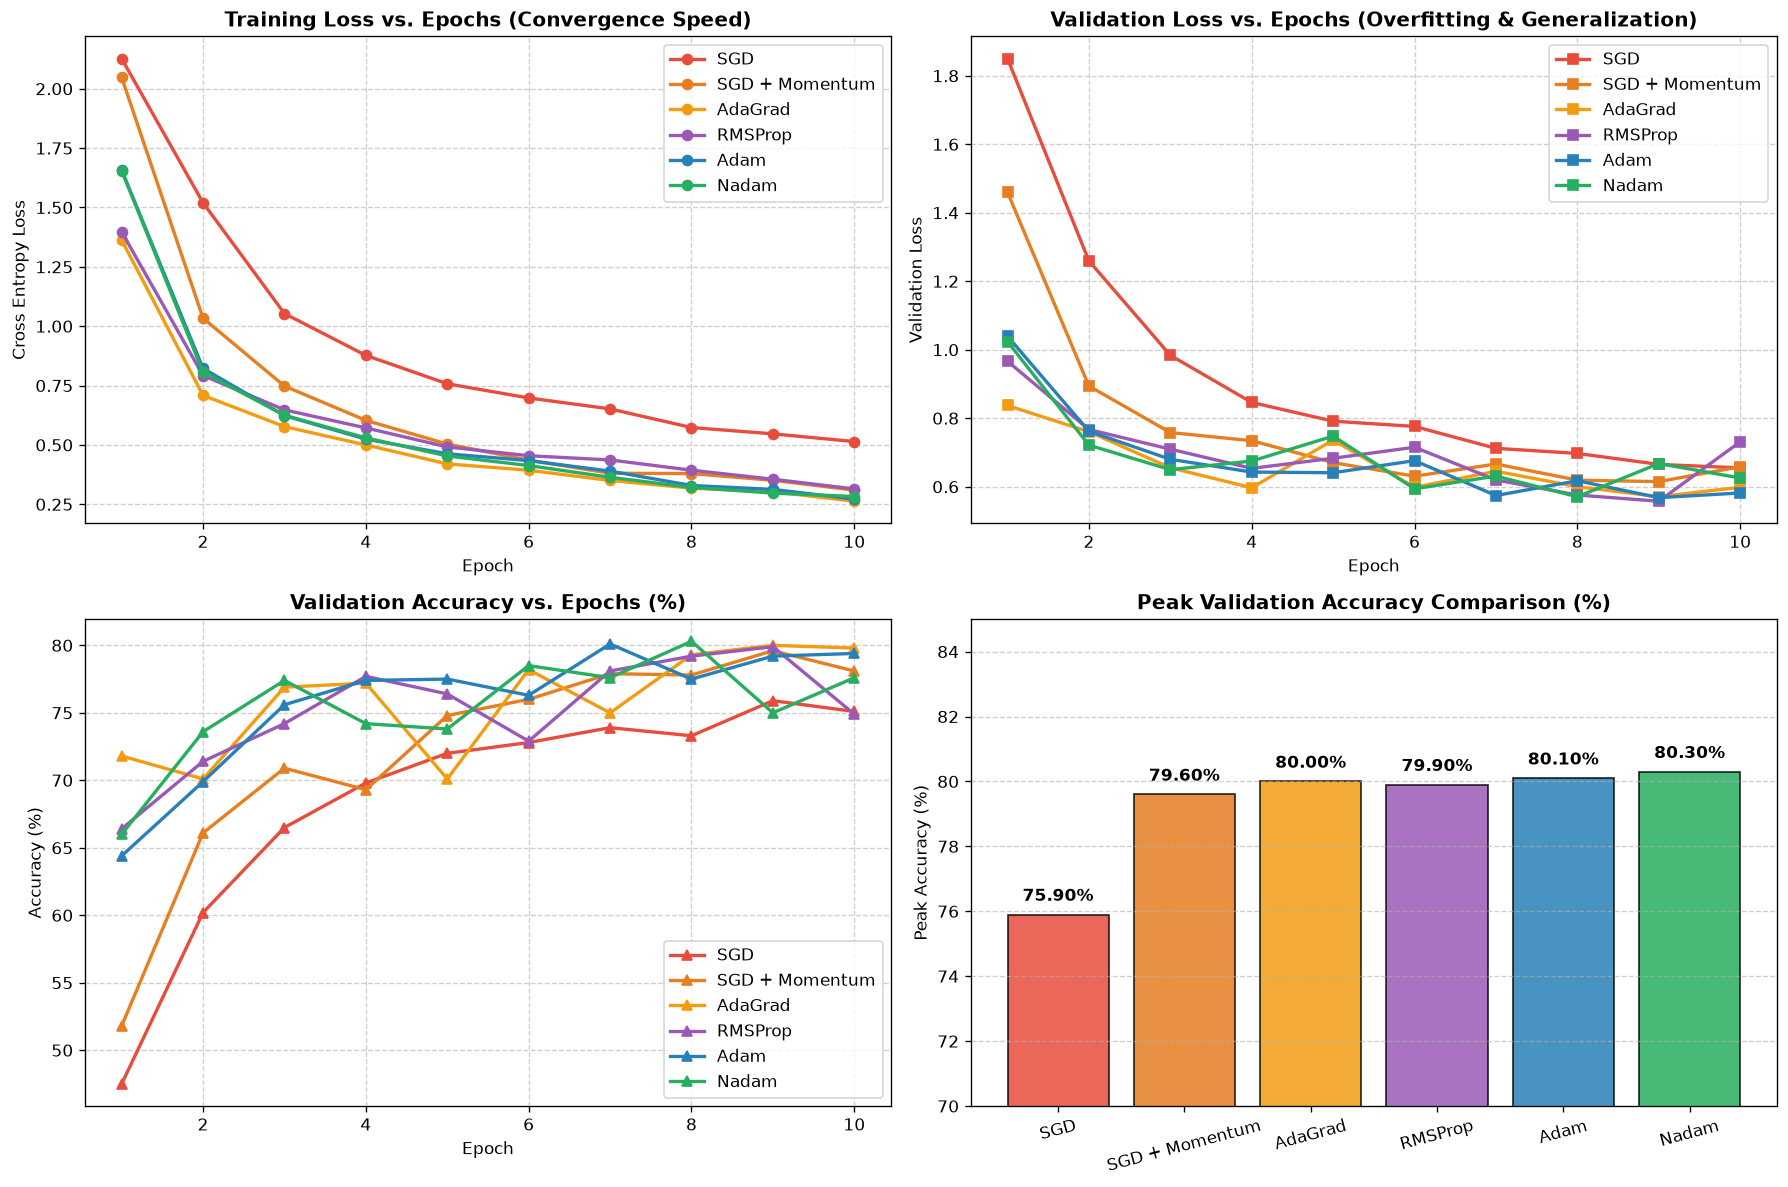

In [9]:
# -------------------------------------------------------------
# STEP 6: Combined Dashboard - All 6 Optimizers on One Canvas
# -------------------------------------------------------------
epochs_axis = list(range(1, 11))
color_map = {
    "SGD": "#e74c3c",
    "SGD + Momentum": "#e67e22",
    "AdaGrad": "#f39c12",
    "RMSProp": "#9b59b6",
    "Adam": "#2980b9",
    "Nadam": "#27ae60"
}

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Subplot 1: All Training Losses
for name, hist in all_benchmark_results.items():
    axs[0, 0].plot(epochs_axis, hist["train_loss"], label=name, color=color_map[name], marker='o', linewidth=2)
axs[0, 0].set_title("Training Loss vs. Epochs (Convergence Speed)", fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Cross Entropy Loss")
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle="--", alpha=0.6)

# Subplot 2: All Validation Losses
for name, hist in all_benchmark_results.items():
    axs[0, 1].plot(epochs_axis, hist["val_loss"], label=name, color=color_map[name], marker='s', linewidth=2)
axs[0, 1].set_title("Validation Loss vs. Epochs (Overfitting & Generalization)", fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Validation Loss")
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle="--", alpha=0.6)

# Subplot 3: All Validation Accuracies
for name, hist in all_benchmark_results.items():
    axs[1, 0].plot(epochs_axis, hist["val_acc"], label=name, color=color_map[name], marker='^', linewidth=2)
axs[1, 0].set_title("Validation Accuracy vs. Epochs (%)", fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Accuracy (%)")
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle="--", alpha=0.6)

# Subplot 4: Peak Validation Accuracy Bar Chart
df_comparison = pd.DataFrame(summary_table_rows)
opts = df_comparison["Optimizer"].tolist()
peaks = df_comparison["Peak Val Acc (%)"].tolist()
bars = axs[1, 1].bar(opts, peaks, color=[color_map[o] for o in opts], alpha=0.85, edgecolor='black')
axs[1, 1].set_ylim(70, 85)
axs[1, 1].set_title("Peak Validation Accuracy Comparison (%)", fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel("Peak Accuracy (%)")
for bar in bars:
    y = bar.get_height()
    axs[1, 1].text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')
axs[1, 1].tick_params(axis='x', rotation=15)
axs[1, 1].grid(True, axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
os.makedirs("./plots", exist_ok=True)
fig.savefig("./plots/all_optimizers_comparison.png", dpi=250, bbox_inches='tight')
plt.show()

df_comparison.to_csv("./plots/benchmark_summary.csv", index=False)
print("\n" + "="*85)
print("FINAL BENCHMARK COMPARISON TABLE (1,000 SAMPLES)")
print("="*85)
print(df_comparison.to_string(index=False))


## 10. Learning Rate Sensitivity Benchmark

How gracefully does each optimizer degrade when the learning rate is off by orders of magnitude?
We test $\eta \in [10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}]$ for 3 epochs each:


[+] Evaluating learning rate sensitivity across 4 decades...
  > SGD             @ lr=0.1     | 3-Epoch Val Acc = 58.80%
  > SGD             @ lr=0.01    | 3-Epoch Val Acc = 40.60%
  > SGD             @ lr=0.001   | 3-Epoch Val Acc = 12.20%
  > SGD             @ lr=0.0001  | 3-Epoch Val Acc = 7.00%
  > SGD + Momentum  @ lr=0.1     | 3-Epoch Val Acc = 70.90%
  > SGD + Momentum  @ lr=0.01    | 3-Epoch Val Acc = 69.40%
  > SGD + Momentum  @ lr=0.001   | 3-Epoch Val Acc = 37.90%
  > SGD + Momentum  @ lr=0.0001  | 3-Epoch Val Acc = 10.80%
  > AdaGrad         @ lr=0.1     | 3-Epoch Val Acc = 70.70%
  > AdaGrad         @ lr=0.01    | 3-Epoch Val Acc = 70.90%
  > AdaGrad         @ lr=0.001   | 3-Epoch Val Acc = 70.60%
  > AdaGrad         @ lr=0.0001  | 3-Epoch Val Acc = 37.50%
  > Adam            @ lr=0.1     | 3-Epoch Val Acc = 32.70%
  > Adam            @ lr=0.01    | 3-Epoch Val Acc = 74.60%
  > Adam            @ lr=0.001   | 3-Epoch Val Acc = 74.50%
  > Adam            @ lr=0.0001  | 3-Epo

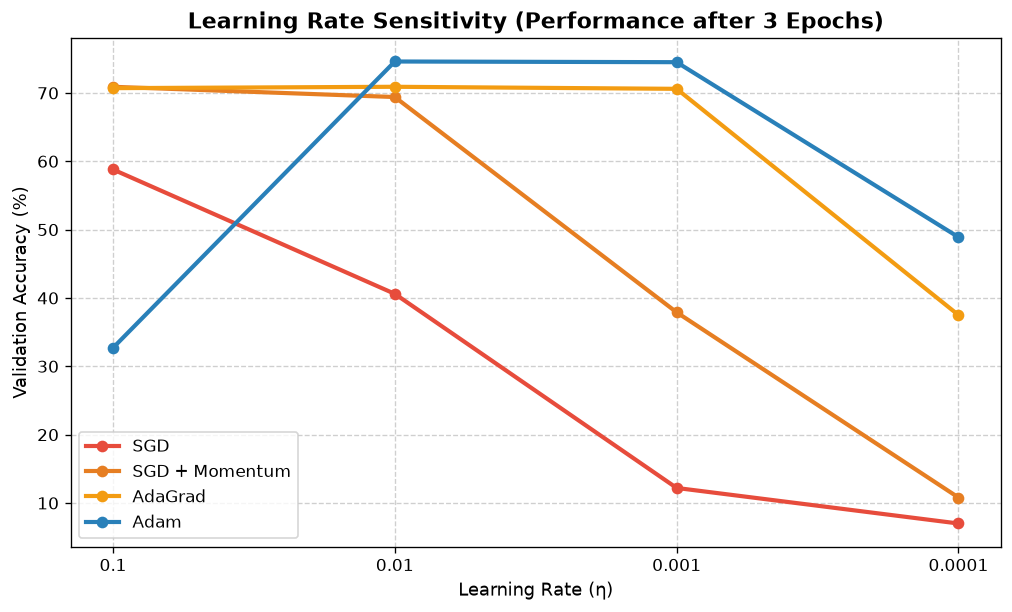

In [10]:
# -------------------------------------------------------------
# STEP 7: Multi-Decade Learning Rate Sensitivity Sweep
# -------------------------------------------------------------
lrs = [0.1, 0.01, 0.001, 0.0001]
test_opts = ["SGD", "SGD + Momentum", "AdaGrad", "Adam"]
sens_results = {opt: [] for opt in test_opts}

def get_sens_opt(opt_name, model_inst, lr):
    if opt_name == "SGD":
        return optim.SGD(model_inst.parameters(), lr=lr)
    elif opt_name == "SGD + Momentum":
        return optim.SGD(model_inst.parameters(), lr=lr, momentum=0.9)
    elif opt_name == "AdaGrad":
        return optim.Adagrad(model_inst.parameters(), lr=lr)
    elif opt_name == "Adam":
        return optim.Adam(model_inst.parameters(), lr=lr)

print("[+] Evaluating learning rate sensitivity across 4 decades...")
for opt in test_opts:
    for lr in lrs:
        set_seed(42)
        m = BenchmarkMLP().to(device)
        m.load_state_dict(copy.deepcopy(initial_weights))
        optimizer = get_sens_opt(opt, m, lr)
        
        m.train()
        for ep in range(3):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out = m(x)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
                
        _, acc = evaluate_model(m, val_loader)
        sens_results[opt].append(acc)
        print(f"  > {opt:15s} @ lr={lr:<7} | 3-Epoch Val Acc = {acc:.2f}%")

# Plot Sensitivity Curve
plt.figure(figsize=(10, 5.5))
for opt in test_opts:
    plt.plot([str(lr) for lr in lrs], sens_results[opt], marker='o', linewidth=2.5, 
             label=opt, color=color_map[opt])

plt.title("Learning Rate Sensitivity (Performance after 3 Epochs)", fontsize=13, fontweight='bold')
plt.xlabel("Learning Rate (\u03b7)", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("./plots/learning_rate_sensitivity.png", dpi=200, bbox_inches='tight')
plt.show()


## 11. The Generalization Mystery: Adam vs. SGD + Momentum

### Key Question:
> *"Why does Adam converge faster during training, yet SGD with Momentum often produces better generalization on unseen test data?"*

### The Answer: Flat vs. Sharp Minima
1. **Optimization Speed $\neq$ Model Quality:** Fast drop in training loss does not guarantee superior performance on unseen distributions.
2. **Sharp Minima (Adam):** Because Adam adaptively scales coordinates, it easily slips into narrow, sharp crevices. In a sharp minimum, a tiny shift between training and test sets causes an exponential error surge.
3. **Flat Minima (SGD + Momentum):** Because SGD+Momentum uses uniform step sizes and kinetic velocity, it bounces out of sharp crevices and settles into broad, flat valleys. In a flat minimum, small distributional shifts produce virtually no change in test accuracy.

```
 Loss
  ▲
  │       Sharp Minimum (Adam)           Flat Minimum (SGD + Momentum)
  │       High Test Error Shift             Low Test Error Shift
  │
  │           \     /                              \             /
  │            \   /                                \___________/
  │             \_/
  │          Training: Low Loss               Training: Low Loss
  │          Testing:  HIGH ERROR             Testing:  LOW ERROR
  └───────────────────────────────────────────────────────────────────► Weights (θ)
```

---

## 12. Viva Defense Quick Reference (10-Second Answers)

* **Q1: What optimizer for sparse gradients?**  
  *Answer:* **AdaGrad or Adam**, because their adaptive second moment divides by historical squared gradients, automatically amplifying updates for rare features.
* **Q2: What optimizer for noisy gradients?**  
  *Answer:* **SGD with Momentum or Adam**, because the first-moment running average acts as a low-pass filter, dampening noisy oscillations.
* **Q3: How to escape saddle points?**  
  *Answer:* **Adam or SGD + Momentum**, because accumulated velocity carries parameters across flat zero-gradient plateaus.
* **Q4: Why divide by $(1-\beta^t)$ in Adam?**  
  *Answer:* Because moment vectors are initialized at zero; dividing by $(1-\beta^t)$ cancels out the initialization bias during early iterations.
